# Projekt MSP1 / 2024
Cílem tohoto projektu je se seznámit s programovými nástroji využívaných ve statistice a osvojit si základní procedury. Projekt není primárně zaměřen na efektivitu využívání programového vybavení (i když úplně nevhodné konstrukce mohou mít vliv na hodnocení), ale nejvíce nás zajímají vaše statistické závěry a způsob vyhodnocení. Dbejte také na to, že každý graf musí splňovat nějaké podmínky - přehlednost, čitelnost, popisky.

V projektu budete analyzovat časy běhu šesti různých konfigurací algoritmů. Ke každé konfiguraci vzniklo celkem 200 nezávislých běhů, jejichž logy máte k dispozici v souboru [logfiles.zip](logfiles.zip).

Pokud nemáte rozchozené prostředí pro pro spouštění Jupyter notebooku, můžete využití službu [Google Colab](https://colab.google/). Jakákoliv spolupráce, sdílení řešení a podobně je zakázána!

S případnými dotazy se obracejte na Vojtěcha Mrázka (mrazek@fit.vutbr.cz).

__Odevzdání:__ tento soubor (není potřeba aby obsahoval výstupy skriptů) do neděle 27. 10. 2024 v IS VUT. Kontrola bude probíhat na Pythonu 3.12.3 (standardní instalace Ubuntu); neočekává se však to, že byste používali nějaké speciality a nekompatibilní knihovny. V případě nesouladu verzí a podobných problémů budete mít možnost reklamace a prokázání správnosti funkce. Bez vyplnění vašich komentářů a závěrů do označených buněk nebude projekt hodnocen!

__Upozornění:__ nepřidávejte do notebooku další buňky, odpovídejte tam, kam se ptáme (textové komentáře do Markdown buněk)

__Tip:__ před odevzdáním resetujte celý notebook a zkuste jej spustit od začátku. Zamezíte tak chybám krokování a editací, kdy výsledek z buňky na konci použijete na začátku.

__OTÁZKA K DOPLNĚNÍ:__

_Jméno:_ Samuel Kuchta

_Login:_ xkucht11 221709

## Načtení potřebných knihoven
Načtěte knihovny, které jsou nutné pro zpracování souborů a práci se statistickými funkcemi.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import json
from zipfile import ZipFile

## Načtení dat do DataFrame
Ze souboru `logfiles.zip` umístěném ve stejném adresáři načtěte data a vytvořte Pandas DataFrame.

Výsledky jsou uložené ve formátu JSON - pro zpracování použijte knihovnu `json`.
Můžete využít následující kostru - je vhodné pracovat přímo se ZIP souborem. Jedinou nevýhodou může být to, že vám bude vracet _byte_ objekt, který musíte přes funkci `decode` zpracovat.

Upravte také pomocí funkce `.astype()` datové typy patřičných sloupců.

```py
data = []
with ZipFile("logfiles.zip") as zf:
    for filename in zf.namelist():
        # TODO test názvu souboru
        with zf.open(filename, "r") as f:
            pass # vytvořte slovník

df = pd.DataFrame(data)
df
```

In [2]:
data = []
with ZipFile("logfiles.zip") as zf:
    for filename in zf.namelist():
        if filename.endswith('.json'):  # Zkontroluje, zda se jedná o JSON soubor
            with zf.open(filename, "r") as f:
                file_content = f.read().decode('utf-8')  # Dekóduje byte objekt na řetězec
                json_content = json.loads(file_content)
                data.append(json_content)

df = pd.DataFrame(data)

# Nastaví správné datové typy pro relevantní sloupce
df['run'] = df['run'].astype(int)
df['runtime'] = df['runtime'].astype(float)

df


,configuration,run,runtime,status
0,config6,149,53.733556,SUCCESS
1,config2,16,134.543496,SUCCESS
2,config6,180,117.108040,SUCCESS
3,config4,12,223.763044,SUCCESS
4,config5,193,159.540473,SUCCESS
...,...,...,...,...
1195,config5,95,199.461297,SUCCESS
1196,config5,99,155.491930,SUCCESS
1197,config2,83,125.243690,SUCCESS
1198,config5,153,223.312938,SUCCESS


## Analýza a čištění dat
Vhodným způsobem pro všechny konfigurace analyzujte časy běhů a pokud tam jsou, identifikujte hodnoty, které jsou chybné. Vyberte vhodný graf, který zobrazí samostatně jednotlivé konfigurace.

               count        mean         std       min         25%  \
configuration                                                        
config1        200.0  123.104749  208.128584  0.000000   92.716828   
config2        200.0  167.456980  166.009023  0.000000  137.883249   
config3        200.0  144.151535  120.874132  0.000000  123.891821   
config4        200.0  143.054033  174.673555  0.000000   93.049865   
config5        200.0  198.904871  164.334180  0.000000  163.910896   
config6        200.0  118.870575  126.237033  2.124534   81.741231   

                      50%         75%     max  
configuration                                  
config1         99.799944  105.008525  1800.0  
config2        151.576787  165.004250  1800.0  
config3        138.038496  151.533715  1800.0  
config4        129.975246  165.023842  1800.0  
config5        183.916111  201.549486  1800.0  
config6        111.088189  137.889290  1800.0  


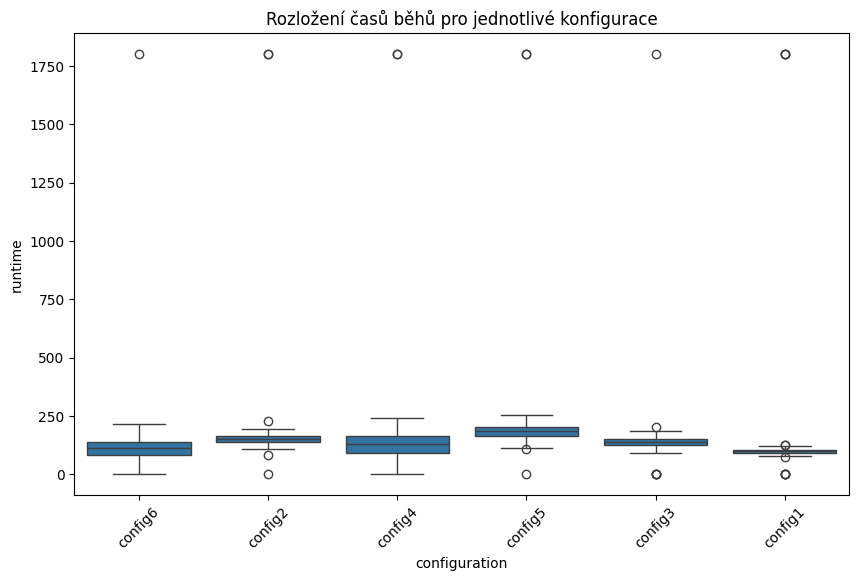

Počet odlehlých hodnot: 30
     configuration  run      runtime      status
6          config5  103  1800.000000  TIME LIMIT
42         config3   41     0.000000    SEGFAULT
51         config1   62     0.000000    SEGFAULT
92         config2  142     0.000000    SEGFAULT
99         config1  134  1800.000000  TIME LIMIT
104        config2   40  1800.000000  TIME LIMIT
105        config4   56     0.000000    SEGFAULT
230        config5  118     0.000000    SEGFAULT
301        config3   78   201.577616     SUCCESS
318        config3  184     0.000000    SEGFAULT
327        config4  110  1800.000000  TIME LIMIT
367        config1  184     0.000000    SEGFAULT
381        config4   60     0.000000    SEGFAULT
384        config1  113   124.632421     SUCCESS
565        config3  166  1800.000000  TIME LIMIT
608        config2   62    85.174653     SUCCESS
642        config4   76  1800.000000  TIME LIMIT
692        config5  177   107.283620     SUCCESS
758        config1    9  1800.000000  TIME

In [3]:
# Základní statistiky pro každou konfiguraci
config_stats = df.groupby('configuration')['runtime'].describe()
print(config_stats)

# Vizuální analýza - boxplot pro detekci odlehlých hodnot
plt.figure(figsize=(10, 6))
sns.boxplot(x='configuration', y='runtime', data=df)
plt.title('Rozložení časů běhů pro jednotlivé konfigurace')
plt.xticks(rotation=45)
plt.show()

# Detekce odlehlých hodnot pomocí IQR
Q1 = df.groupby('configuration')['runtime'].quantile(0.25)
Q3 = df.groupby('configuration')['runtime'].quantile(0.75)
IQR = Q3 - Q1

# Stanovení limitů pro odlehlé hodnoty
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identifikace chybně vysokých nebo nízkých hodnot
def is_outlier(row):
    config = row['configuration']
    return row['runtime'] < lower_bound[config] or row['runtime'] < 0.01 or row['runtime'] > upper_bound[config] or row['runtime'] > 1799

# Filtrace outliers
outliers = df[df.apply(is_outlier, axis=1)]


# Zobrazení odlehlých hodnot
print("Počet odlehlých hodnot:", len(outliers))
print(outliers)


__OTÁZKA K DOPLNĚNÍ:__

_Objevily se nějaké chybné hodnoty? Proč tam jsou s ohledem na to, že se jedná o běhy algoritmů? Proč jste zvolili tento typ grafu?_

Hodně outlierů bylo pro čas 0 kvůli segfaultu, a pro čas 1800 kvůli TIME LIMIT.
Boxplot jsem zvolil, protože hezky zobrazuje rozložení hodnot podle kvartilů.


Vyčistěte dataframe `df` tak, aby tam tyto hodnoty nebyly a ukažte znovu analýzu toho, že čištění dat bylo úspěšné. Odtud dále pracujte s vyčištěným datasetem.

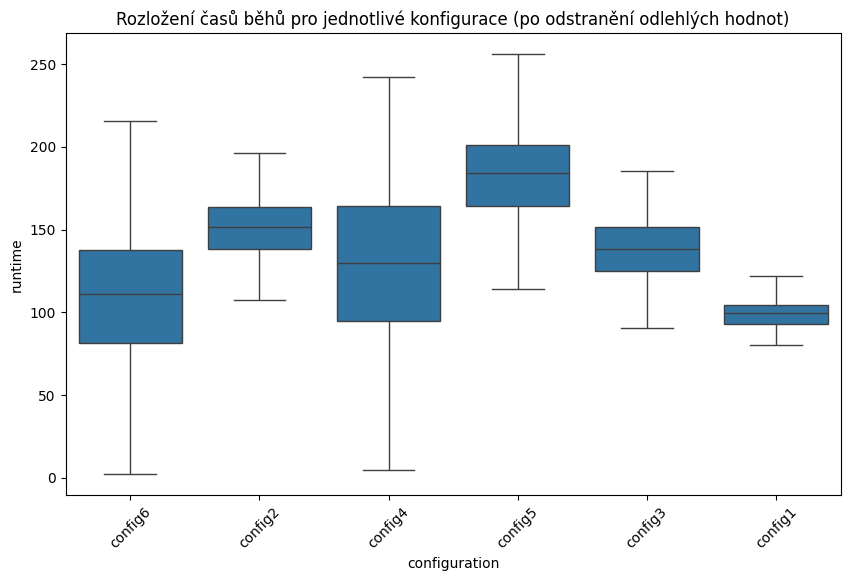

In [4]:
df = df[~df.apply(is_outlier, axis=1)]

# Boxplot bez odlehlých hodnot
plt.figure(figsize=(10, 6))
sns.boxplot(x='configuration', y='runtime', data=df)
plt.title('Rozložení časů běhů pro jednotlivé konfigurace (po odstranění odlehlých hodnot)')
plt.xticks(rotation=45)
plt.show()

## Deskriptivní popis hodnot
Vypište pro jednotlivé konfigurace základní deskriptivní parametry.  

__TIP__ pokud výsledky uložíte jako Pandas DataFrame, zobrazí se v tabulce.

In [5]:
descriptive_stats = df.groupby('configuration')['runtime'].describe() # základní deskriptivní statistiky pro jednotlivé konfigurace

descriptive_stats_df = pd.DataFrame(descriptive_stats)
print(descriptive_stats_df)

               count        mean        std         min         25%  \
configuration                                                         
config1        190.0   99.449016   8.866788   80.124311   93.034540   
config2        195.0  151.688034  18.583050  107.522086  138.003905   
config3        194.0  138.292420  19.393682   90.567110  124.769359   
config4        196.0  127.606156  50.282164    4.970286   94.793688   
config5        196.0  184.049441  28.276656  114.035821  164.072975   
config6        199.0  110.422689  40.875754    2.124534   81.656211   

                      50%         75%         max  
configuration                                      
config1         99.799944  104.737728  121.904556  
config2        151.516091  163.764042  196.293171  
config3        138.448002  151.501348  185.413857  
config4        129.975246  164.327163  241.987620  
config5        183.916111  201.255548  255.807973  
config6        111.043642  137.554141  215.295283  


__OTÁZKA K DOPLNĚNÍ:__

_Okomentujte, co všechno můžeme z parametrů vyčíst._

count: Všechny konfigurace mají dostatečný počet běhů, abychom mohli provést smysluplnou analýzu.

mean: config1 nejrychlejší, config5 nejpomalejší.

std: config1 nejmenší odchylka, config4 (a taky config6) největší odchylka, co může být problém v realtime aplikacích.

## Vizualizace
Vizualizujte časy běhů algoritmů tak, aby byl v jednom grafu zřejmý i rozptyl hodnot, avšak bylo možné porovnání. Zvolte vhodný graf, který pak níže komentujte.

C:\Users\Pavol\AppData\Local\Temp\ipykernel_4876\2655817824.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(ax=axes[1], x='configuration', y='runtime', data=df, palette='Set2')


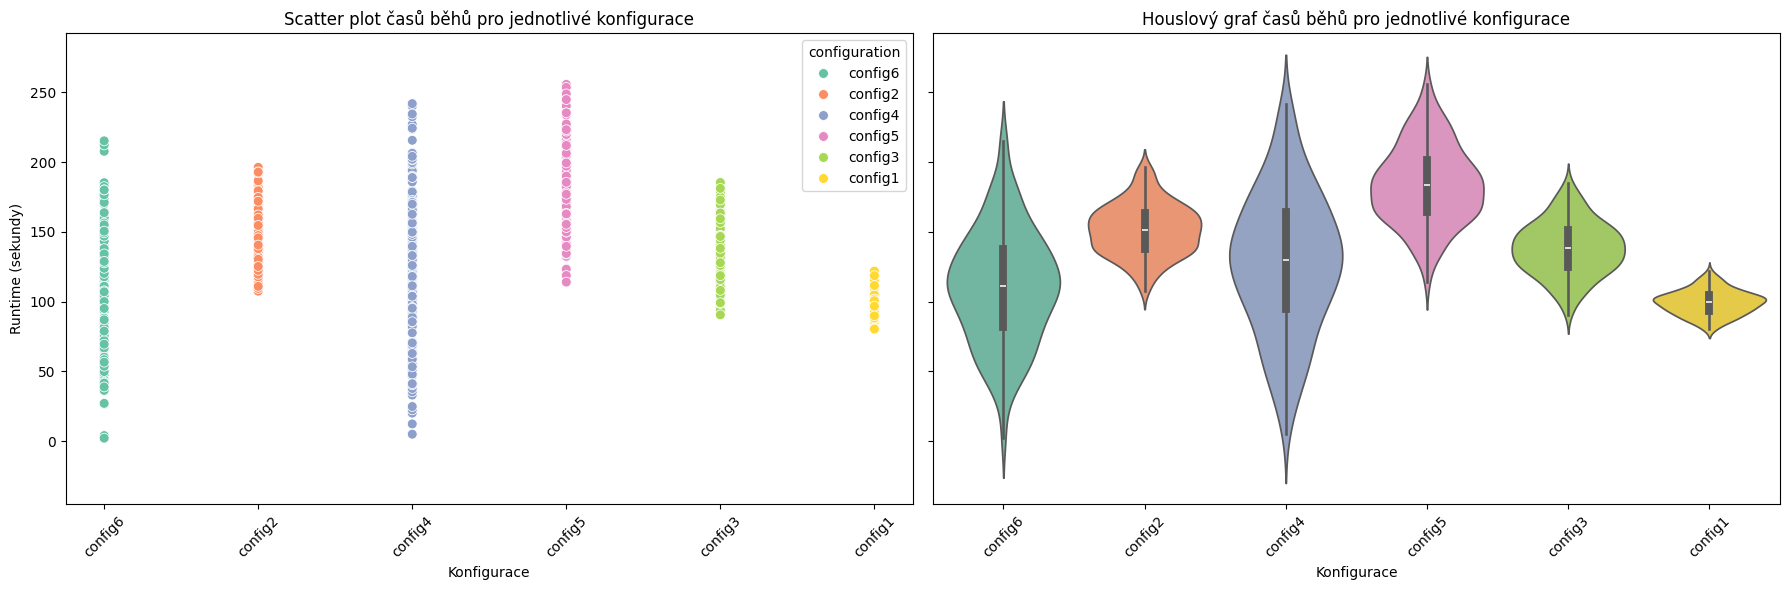

In [6]:
# Vytvoření 2 podgrafů vedle sebe
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# Scatter graf v prvním podgrafu
sns.scatterplot(ax=axes[0], x='configuration', y='runtime', data=df, hue='configuration', palette='Set2', s=50)
axes[0].set_title('Scatter plot časů běhů pro jednotlivé konfigurace')
axes[0].set_xlabel('Konfigurace')
axes[0].set_ylabel('Runtime (sekundy)')
axes[0].tick_params(axis='x', rotation=45)

# Houslový graf ve druhém podgrafu
sns.violinplot(ax=axes[1], x='configuration', y='runtime', data=df, palette='Set2')
axes[1].set_title('Houslový graf časů běhů pro jednotlivé konfigurace')
axes[1].set_xlabel('Konfigurace')
axes[1].tick_params(axis='x', rotation=45)

# Úprava rozložení a zobrazení grafu
plt.tight_layout()
plt.show()

__OTÁZKA K DOPLNĚNÍ:__

_Okomentujte  výsledky z tabulky._

config4/5/6 obsahují v scatter grafu viditelné mezery, tvořící menší ostrůvky poblíž extrémních hodnot. co naznačuje přítomnost více normálních rozložení. (možná běhy odpovídající jiné hodnotě STATUS než SUCCESS)

## Určení efektivity konfigurací algoritmů
Nás ale zajímá, jaká konfigurace je nejrychlejší. Z výše vykresleného grafu můžeme vyloučit některé konfigurace. Existuje tam však minimálně jedna dvojice, u které nedokážeme jednoznačně určit, která je lepší - pokud nebudeme porovnávat pouze extrémní hodnoty, které mohou být dané náhodou, ale celkově. Proto proveďte vhodný test významnosti - v následující části diskutujte zejména rozložení dat (i s odkazem na předchozí buňky, variabilitu vs polohu a podobně). Je nutné každý logický krok a výběry statistických funkcí komentovat. 

Vužijte vhodnou funkci z knihovny `scipy.stats` a funkci poté __implementujte sami__ na základě základních matematických funkcí knihovny `numpy` případně i funkcí pro výpočet vybraného rozložení v [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html). Při vlastní implementaci není nutné se primárně soustředit na efektivitu výpočtu (není potřeba využít všechny funkce numpy, můžete použít normální cykly a podobně - v hodnocení však bude zahrnuta přehlednost a neměly by se objevit jasné chyby, jako je zvýšení třídy složitosti a podobně).

__OTÁZKA K DOPLNĚNÍ:__

_Jaká data budete zkoumat? Jaké mají rozložení a parametry (např. varianci) a jaký test použijete? Jaká je nulová hypotéza? Jak se liší variabilita a poloha vybraných konfigurací?_

In [7]:
conf2 = df[df['configuration'] == 'config2']['runtime']
conf3 = df[df['configuration'] == 'config3']['runtime']

# Test normality pomocí Shapiro-Wilk testu
shapiro_config2 = stats.shapiro(conf2)
shapiro_config3 = stats.shapiro(conf3)

print(f'Shapiro-Wilk test pro config2: p-hodnota = {shapiro_config2.pvalue}')
print(f'Shapiro-Wilk test pro config3: p-hodnota = {shapiro_config3.pvalue}')

if shapiro_config2.pvalue > 0.05 and shapiro_config3.pvalue > 0.05:
  print("Nulovou hypotézu, že data pocházejí z normálního rozdělení, nelze zamítnout.")
  
  # T-test pro dvě nezávislé skupiny
  t_stat, p_value = stats.ttest_ind(conf2, conf3)
  print(f'T-test: t-statistika = {t_stat}, p-hodnota = {p_value}')

  if p_value < 0.001:
    print("config2 a config3 pocházejí z odlišných normálních rozdělení s 99.9% věrností.")

else:
  print("Data nepocházejí z normálního rozdělení s 95% věrností.")




Shapiro-Wilk test pro config2: p-hodnota = 0.42148105777568556
Shapiro-Wilk test pro config3: p-hodnota = 0.8374173595659102
Nulovou hypotézu, že data pocházejí z normálního rozdělení, nelze zamítnout.
T-test: t-statistika = 6.95574175185022, p-hodnota = 1.5029739150997362e-11
config2 a config3 pocházejí z odlišných normálních rozdělení s 99.9% věrností.


__OTÁZKA K DOPLNĚNÍ:__

_Jaký je závěr statistického testu?_

konfigurace se od sebe významně liší, takže se můžeme celkem spolehlivě řídit výsledkami deskriptivního popisu hodnot.

### Vlastní implementace
Implementujte stejný test pomocí knihovních funkcí a ukažte, že je výsledek stejný.

In [8]:
import numpy as np

# Vlastní implementace t-testu
def my_t_test(group1, group2):
    mean1, mean2 = np.mean(group1), np.mean(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    n1, n2 = len(group1), len(group2)

    # Výpočet t-statistiky
    t_stat = (mean1 - mean2) / np.sqrt((var1 / n1) + (var2 / n2))
    return t_stat

# Použití vlastní implementace
t_stat_mine = my_t_test(conf2, conf3)
print(f'Knihovní t-test: t-statistic = {t_stat}')
print(f'Ruční t-test: t-statistic = {t_stat_mine}')

if t_stat * 0.999 < t_stat_mine < t_stat * 1.001:
    print("Moje implementace dosahuje rovnakých hodnot. (s malými rozdíly kvůli nepřesnosti floating point aritmetiky)")




Knihovní t-test: t-statistic = 6.95574175185022
Ruční t-test: t-statistic = 6.954976808478761
Moje implementace dosahuje rovnakých hodnot. (s malými rozdíly kvůli nepřesnosti floating point aritmetiky)
